In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name: Agrim Jain
- PRN : 250840128004
- Date : 20-11-25

# Deep Neural Network
## Assignment A05

## Tensor Flow
- Select number of layers
- Select node in each of the layers
- Choose activation function
- multi-class - Fashion MNIST dataset (all 60000 images)
- Implement one or more of following to achieve max accuracy.
    - L1/ L2 Regularization
    - Dropout
    - Batch Normalization
    - Early stopping
- Save model

In [ ]:
###-----------------
### Import Libraries
###-----------------
import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix

In [3]:
###-----------------
### Global Variables
###-----------------
# inpDir = os.path.join('..', '..', 'input')
# outDir = '../output'
# modelDir = '../models'
# subDir = 'fashion_mnist'
# altName = 'A04_fashion_vanila'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible results
tf.random.set_seed(RANDOM_STATE)

# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 8),
          'axes.labelsize': 'large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large'
         }

CMAP = 'brg' # plt.cm.Spectral

plt.rcParams.update(params)


In [4]:
###-----------------
### Hyper Parameters
###-----------------
EPOCHS = 30 # number of epochs
ALPHA = 0.001 # learning rate
BATCH_SIZE = 64 # mini batch size (number of rows)
TRAIN_SIZE = int(18 * BATCH_SIZE)
TEST_SIZE = 0.2
WEIGHT_DECAY = 0.001
PATIENCE = 20
LR_FACTOR = 0.1
LR_PATIENCE = 5
MIN_LR = 1e-6

## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [6]:
# loading data
train_filename = '../../input/fashion_mnist/fashion-mnist_train.csv'
test_filename = '../../input/fashion_mnist/fashion-mnist_test.csv'

train_df = pd.read_csv(train_filename, header = 0)
test_df = pd.read_csv(test_filename, header = 0)

train_df.shape, test_df.shape

((60000, 785), (10000, 785))

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [8]:
# labels
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
              'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# mapping labels to numeric labels
class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [9]:
# checking for missing values
train_df.isna().sum().sum(), test_df.isna().sum().sum()

(np.int64(0), np.int64(0))

In [10]:
# scaling

from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()

X_train = train_df.drop('label', axis=1)
y_train =  train_df['label'].to_numpy()

X_test = test_df.drop('label', axis=1)
y_test = test_df['label'].to_numpy()

X_train = mm.fit_transform(X_train)
X_test = mm.transform(X_test)

type(X_train), type(X_test), type(y_train), type(y_test)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

In [11]:
# 1. convert to data sets
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# 2. shuffle w.r.t size and convert to batch
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(batch_size=BATCH_SIZE)
test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(batch_size=BATCH_SIZE)

# 3. cache and prefetch
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


In [12]:
# weight initializer
initializer = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)
# regularizer = tf.keras.regularizers.L2(0.05)

# dropout rates
dor1 = 0.1
dor2 = 0.2


# model definition
model = tf.keras.Sequential([
    tf.keras.Input(shape=(784,)), # input

    tf.keras.layers.Dense(196, kernel_initializer=initializer),
    tf.keras.layers.BatchNormalization(), # batch normalization
    tf.keras.layers.ReLU(), # activation
    tf.keras.layers.Dropout(dor1), # dropout

    tf.keras.layers.Dense(49, kernel_initializer=initializer),
    tf.keras.layers.BatchNormalization(), # batch normalization
    tf.keras.layers.ReLU(), # activation
    tf.keras.layers.Dropout(dor2), # dropout

    tf.keras.layers.Dense(10, kernel_initializer=initializer) # output
])

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) # loss function   
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA) # optimizer
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy']) # model compilation


In [13]:
# CALLBACKS

# Creates TensorBoard callback for visualization of training metrics
tb_callback = tf.keras.callbacks.TensorBoard(
    log_dir='logs'
)

# Stops training early if validation loss stops improving to prevent overfitting
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    verbose=1,
    restore_best_weights=True  # Fixed typo: restore_best_weight -> restore_best_weights
)

# Defines file path for saving model checkpoints
chkpt_filepath = './best_yet.keras'

# Saves model weights when validation loss improves to keep best performing version
chkpt_callback = tf.keras.callbacks.ModelCheckpoint(
    chkpt_filepath,
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='auto',
    save_freq='epoch',
    initial_value_threshold=None,
)

# Reduces learning rate when validation loss plateaus to help convergence
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(  # Fixed variable name conflict
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_delta=0.0001,
    cooldown=0,
    min_lr=MIN_LR,
)

In [14]:
# model training
history = model.fit(train_ds, validation_data=test_ds, 
                    epochs=EPOCHS, callbacks=[tb_callback, chkpt_callback, reduce_lr_callback, es_callback])


Epoch 1/30
932/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7682 - loss: 0.7050
Epoch 1: val_loss improved from None to 0.41376, saving model to ./best_yet.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8145 - loss: 0.5431 - val_accuracy: 0.8557 - val_loss: 0.4138 - learning_rate: 0.0010
Epoch 2/30
936/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8539 - loss: 0.4070
Epoch 2: val_loss improved from 0.41376 to 0.37875, saving model to ./best_yet.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8581 - loss: 0.3969 - val_accuracy: 0.8630 - val_loss: 0.3788 - learning_rate: 0.0010
Epoch 3/30
930/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8678 - loss: 0.3658
Epoch 3: val_loss improved from 0.37875 to 0.33064, saving model to ./best_yet.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8709 - loss: 0.3570 - val_accuracy: 0.8769 - val_loss: 0.3306 - learning_rate: 0.0010
Epoch 4/30
929/938 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.

### Train pred

In [15]:
y_true, y_pred= [], []
for feature, label in train_ds:
    pred = model(feature).numpy()
    y_true.extend(label)
    y_pred.extend(pred.argmax(axis=1))

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      6000
           1       1.00      0.99      1.00      6000
           2       0.92      0.90      0.91      6000
           3       0.94      0.97      0.96      6000
           4       0.89      0.93      0.91      6000
           5       1.00      0.99      0.99      6000
           6       0.89      0.84      0.86      6000
           7       0.97      0.99      0.98      6000
           8       1.00      1.00      1.00      6000
           9       0.99      0.98      0.98      6000

    accuracy                           0.95     60000
   macro avg       0.95      0.95      0.95     60000
weighted avg       0.95      0.95      0.95     60000



### Test pred

In [16]:
y_true, y_pred = [], []

for feature, label in test_ds:
    pred = model(feature).numpy()
    y_true.extend(label)
    y_pred.extend(pred.argmax(axis=1))

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1000
           1       0.99      0.98      0.99      1000
           2       0.85      0.83      0.84      1000
           3       0.90      0.93      0.91      1000
           4       0.84      0.87      0.86      1000
           5       0.98      0.95      0.96      1000
           6       0.77      0.72      0.75      1000
           7       0.93      0.97      0.95      1000
           8       0.97      0.98      0.98      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



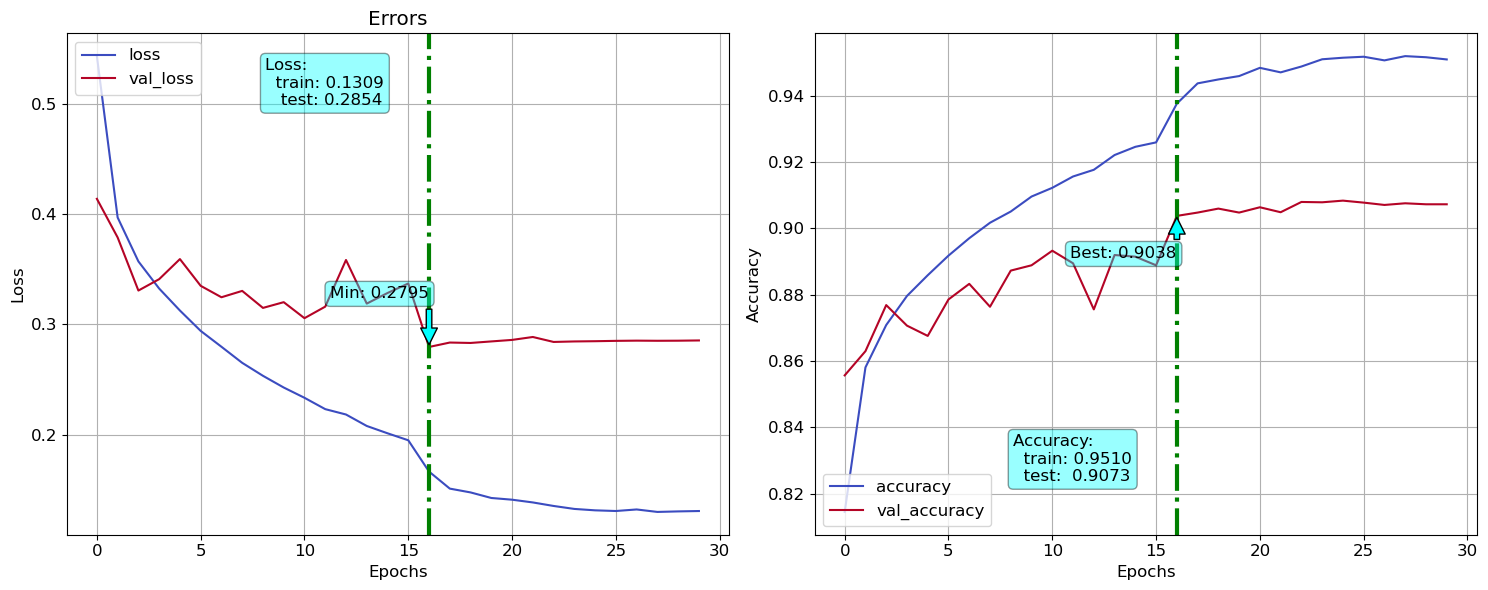

In [17]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

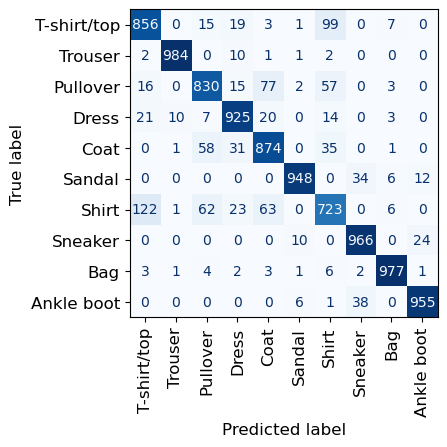

In [18]:
fn_plot_confusion_matrix(y_true, y_pred, class_names)